<a href="https://colab.research.google.com/github/Bima34157/data-science-2026/blob/main/pertemuan_4_zaldi_bima_aditya_220401010271.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-4

- Nama    : Zaldi Bima Aditya
- NIM     : 220401010271
- Kelas   : IF405

# Langkah 1: Import Library & Load Dataset

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = sns.load_dataset('iris')

print("Shape Dataset:")
print(df.shape)

print("Tipe Data:")
print(df.dtypes)

print("5 Data Pertama:")
print(df.head())

print(df.describe().round(3))

Shape Dataset:
(150, 5)
Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
5 Data Pertama:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%        

# Langkah 2: Statistik Deskriptif Lengkap

In [5]:
for col in df.select_dtypes(include='number').columns:
    print(f"\n{'='*40}")
    print(f"Kolom : {col}")
    print(f"{'='*40}")

    print(f"Mean     : {df[col].mean():.3f}")
    print(f"Median   : {df[col].median():.3f}")
    print(f"Std Dev  : {df[col].std():.3f}")
    print(f"Varians  : {df[col].var():.3f}")
    print(f"Skewness : {df[col].skew():.3f}")
    print(f"Kurtosis : {df[col].kurt():.3f}")


Kolom : sepal_length
Mean     : 5.843
Median   : 5.800
Std Dev  : 0.828
Varians  : 0.686
Skewness : 0.315
Kurtosis : -0.552

Kolom : sepal_width
Mean     : 3.057
Median   : 3.000
Std Dev  : 0.436
Varians  : 0.190
Skewness : 0.319
Kurtosis : 0.228

Kolom : petal_length
Mean     : 3.758
Median   : 4.350
Std Dev  : 1.765
Varians  : 3.116
Skewness : -0.275
Kurtosis : -1.402

Kolom : petal_width
Mean     : 1.199
Median   : 1.300
Std Dev  : 0.762
Varians  : 0.581
Skewness : -0.103
Kurtosis : -1.341


# Langkah 3: Histogram + KDE Sepal Length

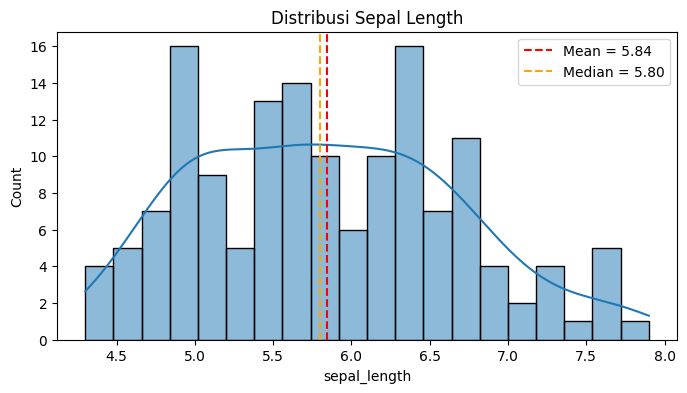

In [7]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='sepal_length',
    kde=True,
    bins=20
)

plt.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

plt.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

plt.title("Distribusi Sepal Length")
plt.legend()
plt.show()



Interpretasi:

- Distribusi sepal_length terlihat mendekati normal.
- Nilai mean dan median berdekatan.
- Tidak terlihat skewness yang sangat ekstrem.
- Sebagian besar data berada pada rentang 5 hingga 7 cm.

# Langkah 4: Boxplot Petal Length per Species

/tmp/ipykernel_620/1113028934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


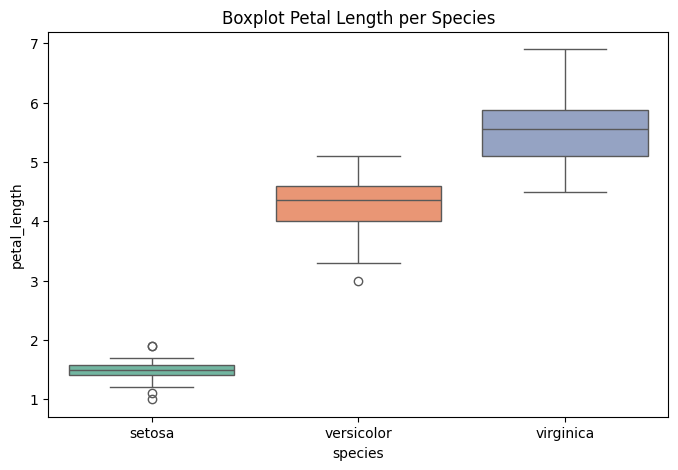

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2'
)

plt.title('Boxplot Petal Length per Species')
plt.show()

Interpretasi:

- Setosa memiliki petal length paling kecil.
- Virginica memiliki petal length paling besar.
- Versicolor berada di antara keduanya.
- Persebaran Virginica paling lebar sehingga variabilitasnya lebih tinggi.

# Langkah 5: Matriks Korelasi Pearson

In [14]:
corr = df.drop('species', axis=1).corr(method='pearson')

print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


# Langkah 6: Scatter Plot & Heatmap

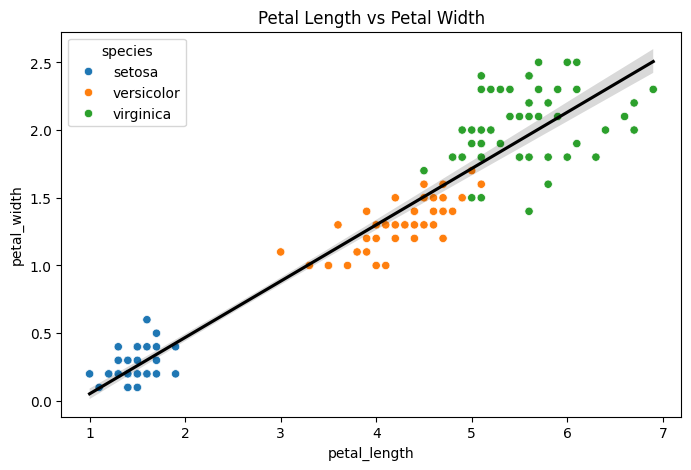

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species'
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='black'
)

plt.title('Petal Length vs Petal Width')
plt.show()




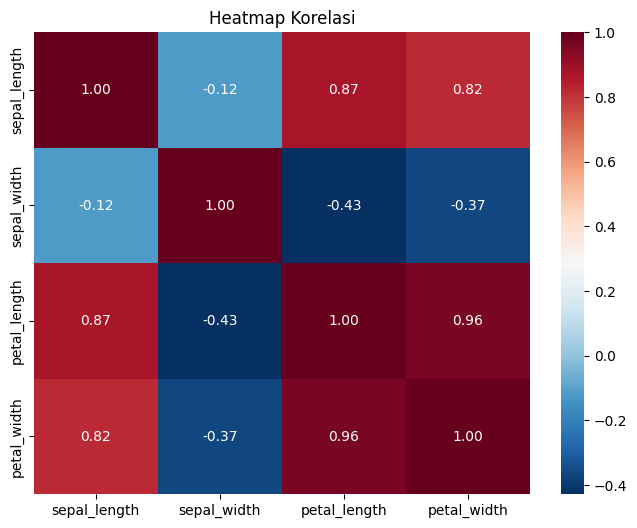

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r'
)

plt.title('Heatmap Korelasi')
plt.show()

Interpretasi:

- Petal Length dan Petal Width memiliki korelasi positif yang sangat kuat.
- Semakin panjang petal bunga maka umumnya semakin lebar petalnya.
- Korelasi tertinggi ditemukan pada pasangan Petal Length dan Petal Width.
- Heatmap menunjukkan sebagian besar variabel memiliki hubungan positif.